<a href="https://colab.research.google.com/github/ramp1401/CodeAlpha/blob/main/Unemplyment_in_india_during_COVID19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

dataset=pd.read_csv("/content/Unemployment in India.csv")
dataset

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
dataset.shapes

(768, 7)

In [4]:
dataset.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [5]:
dataset[dataset.isnull().all(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
dataset.isnull().any(axis=1).sum()

np.int64(28)

In [7]:
# droping all nun rows

dataset = dataset.dropna(how='all')

In [8]:
dataset.shape

(740, 7)

In [9]:
dataset

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [10]:
dataset.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


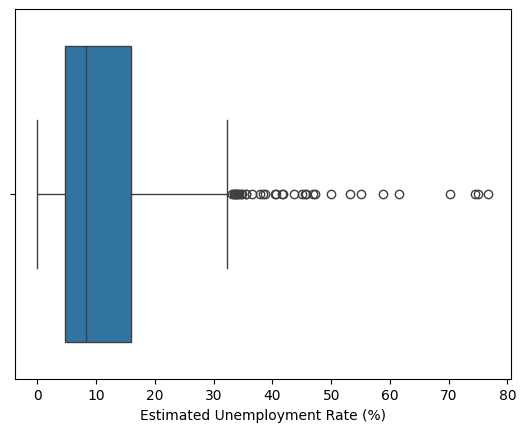

In [11]:
### checking outliers

import seaborn as sns
import matplotlib.pyplot as plt

dataset.columns = dataset.columns.str.strip()

sns.boxplot(x=dataset['Estimated Unemployment Rate (%)'])
plt.show()

In [12]:
Q1 = dataset['Estimated Unemployment Rate (%)'].quantile(0.25)
Q3 = dataset['Estimated Unemployment Rate (%)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dataset[
    (dataset['Estimated Unemployment Rate (%)'] < lower_bound) |
    (dataset['Estimated Unemployment Rate (%)'] > upper_bound)
]

print(outliers)

               Region         Date Frequency  Estimated Unemployment Rate (%)  \
37              Bihar   30-04-2020   Monthly                            45.09   
38              Bihar   31-05-2020   Monthly                            47.26   
105           Haryana   30-04-2020   Monthly                            41.61   
106           Haryana   31-05-2020   Monthly                            34.22   
107           Haryana   30-06-2020   Monthly                            35.57   
144         Jharkhand   30-04-2020   Monthly                            41.72   
145         Jharkhand   31-05-2020   Monthly                            55.10   
158         Karnataka   30-04-2020   Monthly                            33.17   
242        Puducherry   30-04-2020   Monthly                            74.51   
255            Punjab   31-05-2020   Monthly                            40.59   
287        Tamil Nadu   30-04-2020   Monthly                            53.19   
288        Tamil Nadu   31-0

In [13]:
dataset

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [14]:
outliers.count()

,0
Region,35
Date,35
Frequency,35
Estimated Unemployment Rate (%),35
Estimated Employed,35
Estimated Labour Participation Rate (%),35
Area,35


In [15]:
#Caping instead of remove in outliers

import numpy as np
dataset["Estimated Unemployment Rate (%)"] = np.clip(dataset["Estimated Unemployment Rate (%)"], lower_bound, upper_bound)

/tmp/ipykernel_1545/3602222594.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Estimated Unemployment Rate (%)"] = np.clip(dataset["Estimated Unemployment Rate (%)"], lower_bound, upper_bound)


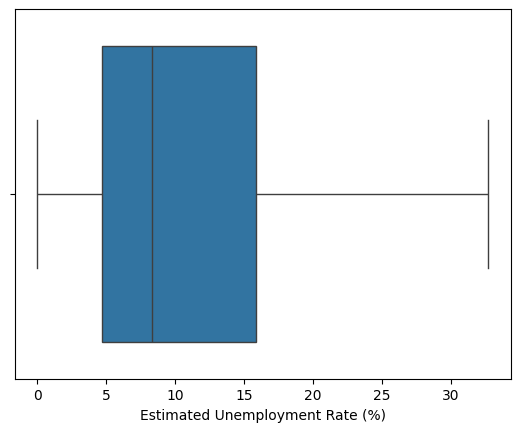

In [16]:
sns.boxplot(x=dataset['Estimated Unemployment Rate (%)'])
plt.show()

In [17]:
## converting date and  year


dataset['Date'] = pd.to_datetime(dataset['Date'])

dataset['year'] = dataset['Date'].dt.year
dataset['month'] = dataset['Date'].dt.month

/tmp/ipykernel_1545/3383520857.py:4: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset['Date'] = pd.to_datetime(dataset['Date'])
/tmp/ipykernel_1545/3383520857.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Date'] = pd.to_datetime(dataset['Date'])
/tmp/ipykernel_1545/3383520857.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['year'] = dataset['Date'].dt.year
/tm

In [18]:
dataset.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,year,month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9


In [19]:
dataset.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

,Estimated Unemployment Rate (%)
Region,
Andhra Pradesh,7.477143
Assam,6.428077
Bihar,16.844643
Chandigarh,15.991667
Chhattisgarh,9.240357
Delhi,16.029375
Goa,9.274167
Gujarat,6.663929
Haryana,25.101518


In [20]:
dataset.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

,Estimated Unemployment Rate (%)
Area,
Rural,9.878677
Urban,12.457329


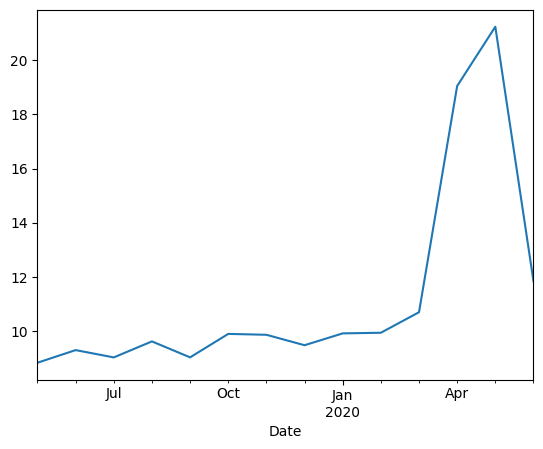

In [21]:

import matplotlib.pyplot as plt

dataset.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot()
plt.show()

In [22]:
y = dataset['Estimated Unemployment Rate (%)']
X = dataset.drop(['Estimated Unemployment Rate (%)', 'Date'], axis=1)

In [23]:
X

,Region,Frequency,Estimated Employed,Estimated Labour Participation Rate (%),Area,year,month
0,Andhra Pradesh,Monthly,11999139.0,43.24,Rural,2019,5
1,Andhra Pradesh,Monthly,11755881.0,42.05,Rural,2019,6
2,Andhra Pradesh,Monthly,12086707.0,43.50,Rural,2019,7
3,Andhra Pradesh,Monthly,12285693.0,43.97,Rural,2019,8
4,Andhra Pradesh,Monthly,12256762.0,44.68,Rural,2019,9
...,...,...,...,...,...,...,...
749,West Bengal,Monthly,10871168.0,44.09,Urban,2020,2
750,West Bengal,Monthly,10806105.0,43.34,Urban,2020,3
751,West Bengal,Monthly,9299466.0,41.20,Urban,2020,4
752,West Bengal,Monthly,9240903.0,40.67,Urban,2020,5


In [24]:
X = pd.get_dummies(X, drop_first=True)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [27]:
## prediction

y_pred = model.predict(X_test)

In [28]:
#evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 3.2370670608108103
RMSE: 4.727087077585431


In [29]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7370285744205203


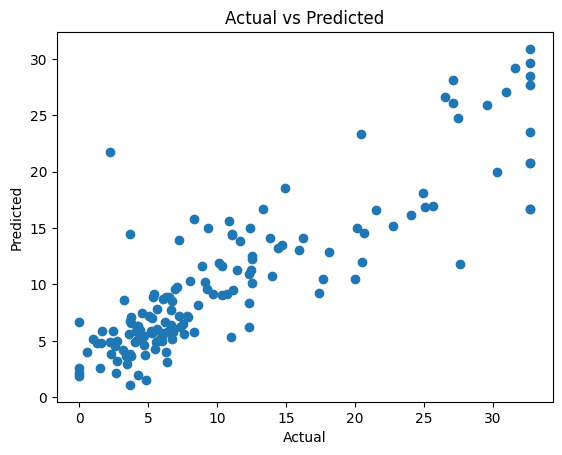

In [30]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

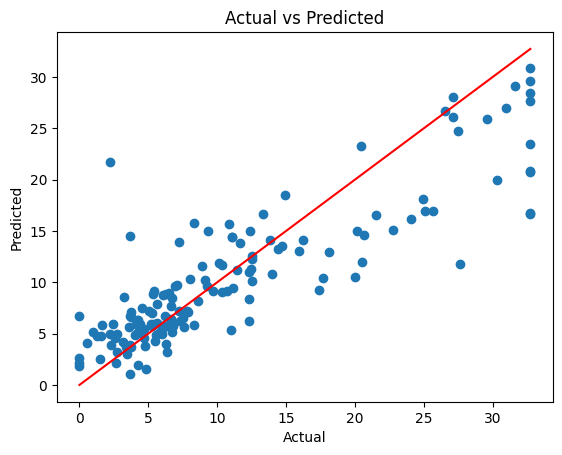

In [35]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

# Add perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()